In [1]:
# ============================================================
# CELL 1 — INSTALL
# ============================================================

!pip install -q -U \
    transformers \
    accelerate \
    bitsandbytes \
    sentencepiece \
    pandas \
    psutil \
    tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 111.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 47.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 98.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 33.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.

In [2]:
# ============================================================
# CELL 2 — LOAD FROZEN GENERATION BENCHMARK
# ============================================================

import json
import gc
import time

import numpy as np
import pandas as pd
import torch

from pathlib import Path


matches = list(
    Path("/kaggle").rglob(
        "docmind_generation_dev_frozen.json"
    )
)

assert matches, (
    "Upload docmind_generation_dev_frozen.json"
)

BENCHMARK_PATH = matches[0]

with open(
    BENCHMARK_PATH,
    "r",
    encoding="utf-8"
) as f:

    benchmark = json.load(f)


records = benchmark["records"]

print("Questions:", len(records))
print(
    "Frozen retrieval:",
    benchmark["retrieval_config"]
)

assert len(records) == 46

Questions: 46
Frozen retrieval: {'chunk_config': 'medium', 'chunk_tokens': 320, 'embedding_model': 'Qwen/Qwen3-Embedding-0.6B', 'retrieval': 'Dense + BM25 RRF', 'reranker': 'BAAI/bge-reranker-v2-m3', 'top_k': 5}


In [3]:
# ============================================================
# CELL 3 — HARDWARE
# ============================================================

print("CUDA:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(
    torch.cuda.device_count()
):
    props = torch.cuda.get_device_properties(i)

    print(
        f"GPU {i}:",
        props.name,
        "|",
        round(
            props.total_memory / 1024**3,
            2
        ),
        "GB"
    )

CUDA: True
GPU count: 2
GPU 0: Tesla T4 | 14.56 GB
GPU 1: Tesla T4 | 14.56 GB


In [10]:
# ============================================================
# CELL 4 — FIXED GROUNDED-RAG PROMPT
# ============================================================

SYSTEM_PROMPT = """
You are DocMind, a grounded document question-answering system.

Rules:
1. Answer using ONLY the provided document sources.
2. Do not use outside knowledge.
3. If the answer cannot be determined from the sources, say exactly:
   "Not found in the provided documents."
4. Answer in the same language as the user's question.
5. Be concise but complete.
6. Cite supporting sources inline using [S1], [S2], etc.
7. Cite only sources that directly support the answer.
8. Never invent a citation.
9. Do not repeat the answer.
10. Do not add a separate references or citations section.
""".strip()


def build_user_prompt(record):

    source_blocks = []

    for ctx in record["contexts"]:

        source_blocks.append(
            f"""
[{ctx['source_id']}]
Document: {ctx['document_id']}
Location: {ctx['location_type']} {ctx['location_value']}
Text:
{ctx['text']}
""".strip()
        )

    sources = "\n\n".join(
        source_blocks
    )

    return f"""
SOURCES

{sources}

QUESTION

{record["question"]}

Answer using only the SOURCES.
""".strip()

In [11]:
print(
    SYSTEM_PROMPT
)

print("\n" + "=" * 100 + "\n")

print(
    build_user_prompt(
        records[0]
    )
)

You are DocMind, a grounded document question-answering system.

Rules:
1. Answer using ONLY the provided document sources.
2. Do not use outside knowledge.
3. If the answer cannot be determined from the sources, say exactly:
   "Not found in the provided documents."
4. Answer in the same language as the user's question.
5. Be concise but complete.
6. Cite supporting sources inline using [S1], [S2], etc.
7. Cite only sources that directly support the answer.
8. Never invent a citation.
9. Do not repeat the answer.
10. Do not add a separate references or citations section.


SOURCES

[S1]
Document: Machine Learning.pptx
Location: slide 8
Text:
Regression
Supervised Machine Learning
Similar to classification, regression is also about inputs and corresponding outputs.
However, outputs for classification are typically discrete types (cat, dog), outputs for regression are a general number. It’s not a 0 or 1, but a sliding scale of possibility.
For example, given a radiological image, a mode

In [12]:
# ============================================================
# CELL 5 — MODEL REGISTRY
# ============================================================

GENERATION_MODELS = {

    "qwen3_4b": {
        "model_name":
            "Qwen/Qwen3-4B-Instruct-2507",
        "trust_remote_code": False,
    },

    "phi4_mini": {
        "model_name":
            "microsoft/Phi-4-mini-instruct",
        "trust_remote_code": True,
    },

    # Enable after accepting Gemma license
    "gemma3_4b": {
        "model_name":
            "google/gemma-3-4b-it",
        "trust_remote_code": False,
    },
}

In [13]:
# ============================================================
# CELL 6 — GENERIC LLM LOADER
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)


QUANT_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_compute_dtype=torch.float16,

    bnb_4bit_use_double_quant=True,
)


def clear_llm():

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_text_llm(model_key):

    clear_llm()

    cfg = GENERATION_MODELS[
        model_key
    ]

    print(
        "Loading:",
        cfg["model_name"]
    )

    tokenizer = (
        AutoTokenizer.from_pretrained(
            cfg["model_name"],
            trust_remote_code=
                cfg["trust_remote_code"]
        )
    )

    model = (
        AutoModelForCausalLM
        .from_pretrained(
            cfg["model_name"],

            quantization_config=
                QUANT_CONFIG,

            device_map="auto",

            trust_remote_code=
                cfg["trust_remote_code"]
        )
    )

    model.eval()

    print("✅ Loaded:", model_key)

    return tokenizer, model

In [14]:
# ============================================================
# CELL 7 — GROUNDED GENERATION
# ============================================================

def generate_answer(
    tokenizer,
    model,
    record,
    max_new_tokens=180
):

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content":
                build_user_prompt(record)
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    )

    input_device = next(
        model.parameters()
    ).device

    inputs = {
        k: v.to(input_device)
        for k, v in inputs.items()
    }

    torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():

        output = model.generate(
            **inputs,

            max_new_tokens=
                max_new_tokens,

            do_sample=False,

            pad_token_id=
                tokenizer.eos_token_id
        )

    torch.cuda.synchronize()

    elapsed = (
        time.perf_counter()
        -
        start
    )

    new_tokens = output[
        0,
        inputs["input_ids"].shape[1]:
    ]

    answer = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()

    generated_tokens = len(
        new_tokens
    )

    return {
        "answer": answer,

        "latency_seconds":
            elapsed,

        "generated_tokens":
            generated_tokens,

        "tokens_per_second":
            generated_tokens / elapsed
            if elapsed > 0
            else 0.0
    }

In [15]:
tokenizer, model = load_text_llm(
    "qwen3_4b"
)

result = generate_answer(
    tokenizer,
    model,
    records[0]
)

print("QUESTION:")
print(records[0]["question"])

print("\nGOLD:")
print(records[0]["expected_answer"])

print("\nMODEL:")
print(result["answer"])

print("\nLatency:")
print(
    result["latency_seconds"],
    "seconds"
)

print(
    "Tokens/sec:",
    result["tokens_per_second"]
)

Loading: Qwen/Qwen3-4B-Instruct-2507


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

✅ Loaded: qwen3_4b
QUESTION:
In the Machine Learning slides, how do regression outputs differ from classification outputs?

GOLD:
Classification outputs are typically discrete types, while regression outputs are general numerical values.

MODEL:
Regression outputs are continuous values (a sliding scale of possibility), such as predicting how many more years an individual will be sick or healthy, whereas classification outputs are discrete types, such as assigning an input to a specific category like "cat" or "dog" [S1]. In regression, the target is a real number, e.g., predicting stock value, while in classification, the target is a class label, e.g., identifying a character in an image [S4].

Latency:
10.37058609099995 seconds
Tokens/sec: 9.353376863066675


In [50]:
# ============================================================
# RUN ONE LLM ON FULL DEV GENERATION BENCHMARK
# ============================================================

from tqdm.auto import tqdm
import json
import torch
from pathlib import Path


def run_generation_benchmark(
    model_key,
    tokenizer,
    model,
    records,
    output_dir,
    max_new_tokens=180
):

    results = []

    output_dir = Path(output_dir)
    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    save_path = (
        output_dir /
        f"{model_key}__dev_generations.json"
    )

    for record in tqdm(
        records,
        desc=f"Generating — {model_key}"
    ):

        # Reset VRAM peak measurement
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        # IMPORTANT:
        # pass model_key so xLAM uses its compatible prompt format
        result = generate_answer(
            tokenizer=tokenizer,
            model=model,
            record=record,
            max_new_tokens=max_new_tokens,
            model_key=model_key
        )

        peak_vram_gb = None

        if torch.cuda.is_available():
            peak_vram_gb = (
                torch.cuda.max_memory_allocated()
                / 1024**3
            )

        row = {
            "question_id":
                record["question_id"],

            "question":
                record["question"],

            "language":
                record["language"],

            "question_type":
                record["question_type"],

            "answerable":
                record["answerable"],

            "expected_answer":
                record.get(
                    "expected_answer"
                ),

            "model_key":
                model_key,

            "answer":
                result["answer"],

            "latency_seconds":
                result["latency_seconds"],

            "generated_tokens":
                result["generated_tokens"],

            "tokens_per_second":
                result["tokens_per_second"],

            "peak_vram_gb":
                peak_vram_gb,
        }

        results.append(row)

        # Incremental save
        with open(
            save_path,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                results,
                f,
                ensure_ascii=False,
                indent=2
            )

    print("\n✅ Benchmark finished")
    print("Model:", model_key)
    print("Questions:", len(results))
    print("Saved:", save_path)

    return results

In [17]:
GENERATION_OUTPUT_DIR = (
    Path("/kaggle/working/docmind_generation_results")
)

qwen_results = run_generation_benchmark(
    model_key="qwen3_4b",
    tokenizer=tokenizer,
    model=model,
    records=records,
    output_dir=GENERATION_OUTPUT_DIR,
    max_new_tokens=180
)

print(
    "✅ Finished:",
    len(qwen_results),
    "questions"
)

Generating — qwen3_4b:   0%|          | 0/46 [00:00<?, ?it/s]

✅ Finished: 46 questions


In [18]:
qwen_df = pd.DataFrame(
    qwen_results
)

display(
    qwen_df[
        [
            "question_id",
            "language",
            "latency_seconds",
            "generated_tokens",
            "tokens_per_second",
            "peak_vram_gb"
        ]
    ]
)


print("=" * 70)
print("QWEN3-4B PERFORMANCE")
print("=" * 70)

print(
    "Questions:",
    len(qwen_df)
)

print(
    "Average latency:",
    round(
        qwen_df[
            "latency_seconds"
        ].mean(),
        3
    ),
    "s"
)

print(
    "Median latency:",
    round(
        qwen_df[
            "latency_seconds"
        ].median(),
        3
    ),
    "s"
)

print(
    "Average tokens/sec:",
    round(
        qwen_df[
            "tokens_per_second"
        ].mean(),
        2
    )
)

print(
    "Average generated tokens:",
    round(
        qwen_df[
            "generated_tokens"
        ].mean(),
        1
    )
)

print(
    "Max observed VRAM:",
    round(
        qwen_df[
            "peak_vram_gb"
        ].max(),
        2
    ),
    "GB"
)

,question_id,language,latency_seconds,generated_tokens,tokens_per_second,peak_vram_gb
0,q037,en,10.424368,97,9.305121,2.460722
1,q032,fr,13.902031,121,8.703764,3.168595
2,q009,fr,12.112094,116,9.577204,2.421203
3,q018,fr,4.200126,32,7.618819,2.648647
4,q007,fr,5.558891,44,7.915247,2.724305
5,q005,fr,4.867710,39,8.011982,2.627388
6,q042,en,6.906071,65,9.412009,2.298244
7,q020,fr,5.616967,39,6.943248,3.044471
8,q031,fr,16.331787,145,8.878392,3.095136
9,q050,en,2.733394,23,8.414448,2.319899


QWEN3-4B PERFORMANCE
Questions: 46
Average latency: 8.675 s
Median latency: 7.216 s
Average tokens/sec: 8.52
Average generated tokens: 76.0
Max observed VRAM: 3.21 GB


In [19]:
sample_ids = [
    0,
    5,
    15,
    25,
    40
]

for i in sample_ids:

    row = qwen_results[i]

    print("\n" + "=" * 100)

    print(
        "QUESTION:",
        row["question"]
    )

    print(
        "\nGOLD:",
        row["expected_answer"]
    )

    print(
        "\nQWEN:",
        row["answer"]
    )


QUESTION: In the Machine Learning slides, how do regression outputs differ from classification outputs?

GOLD: Classification outputs are typically discrete types, while regression outputs are general numerical values.

QWEN: Regression outputs are continuous values (a sliding scale of possibility), such as predicting how many more years an individual will be sick or healthy, whereas classification outputs are discrete types, such as assigning an input to a specific category like "cat" or "dog" [S1]. In regression, the target is a real number, e.g., predicting stock value, while in classification, the target is a class label, e.g., identifying a character in an image [S4].

QUESTION: Quelles utilisations de la décomposition matricielle sont mentionnées à la page sur les valeurs singulières ?

GOLD: La réduction de dimension et la compression de données.

QWEN: Les utilisations de la décomposition matricielle mentionnées à la page sur les valeurs singulières sont la réduction de dimens

In [20]:
QWEN_RESULTS_PATH = (
    GENERATION_OUTPUT_DIR /
    "qwen3_4b__dev_generations.json"
)

assert QWEN_RESULTS_PATH.exists()

print("✅ Qwen results saved")
print(QWEN_RESULTS_PATH)

✅ Qwen results saved
/kaggle/working/docmind_generation_results/qwen3_4b__dev_generations.json


In [21]:
del model
del tokenizer

clear_llm()

print("✅ Qwen unloaded")

✅ Qwen unloaded


In [26]:
GENERATION_MODELS["phi4_mini"] = {
    "model_name": "microsoft/Phi-4-mini-instruct",
    "trust_remote_code": False,   # IMPORTANT
}


In [27]:
clear_llm()

tokenizer, model = load_text_llm(
    "phi4_mini"
)

print("✅ Phi loaded")

Loading: microsoft/Phi-4-mini-instruct


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

✅ Loaded: phi4_mini
✅ Phi loaded


In [28]:
result = generate_answer(
    tokenizer,
    model,
    records[0]
)

print("QUESTION:")
print(records[0]["question"])

print("\nGOLD:")
print(records[0]["expected_answer"])

print("\nPHI:")
print(result["answer"])

print("\nLatency:", round(result["latency_seconds"], 3))
print("Tokens/sec:", round(result["tokens_per_second"], 2))

QUESTION:
In the Machine Learning slides, how do regression outputs differ from classification outputs?

GOLD:
Classification outputs are typically discrete types, while regression outputs are general numerical values.

PHI:
Regression outputs are general numbers, not discrete types like "cat" or "dog" used in classification. Regression predicts a continuous value, such as the number of years an individual will be sick or healthy, based on input features. In contrast, classification outputs are discrete labels that categorize inputs into groups, such as "cat" or "dog". [S1] [S5]

Latency: 6.017
Tokens/sec: 12.96


In [29]:
phi_results = run_generation_benchmark(
    model_key="phi4_mini",
    tokenizer=tokenizer,
    model=model,
    records=records,
    output_dir=GENERATION_OUTPUT_DIR,
    max_new_tokens=180
)

print(
    "✅ Phi finished:",
    len(phi_results),
    "questions"
)

Generating — phi4_mini:   0%|          | 0/46 [00:00<?, ?it/s]

✅ Phi finished: 46 questions


In [30]:
phi_df = pd.DataFrame(phi_results)

print("=" * 70)
print("PHI-4-MINI PERFORMANCE")
print("=" * 70)

print("Questions:", len(phi_df))

print(
    "Average latency:",
    round(phi_df["latency_seconds"].mean(), 3),
    "s"
)

print(
    "Median latency:",
    round(phi_df["latency_seconds"].median(), 3),
    "s"
)

print(
    "Average tokens/sec:",
    round(phi_df["tokens_per_second"].mean(), 2)
)

print(
    "Average generated tokens:",
    round(phi_df["generated_tokens"].mean(), 1)
)

print(
    "Max observed VRAM:",
    round(phi_df["peak_vram_gb"].max(), 2),
    "GB"
)

PHI-4-MINI PERFORMANCE
Questions: 46
Average latency: 5.556 s
Median latency: 3.963 s
Average tokens/sec: 11.58
Average generated tokens: 70.8
Max observed VRAM: 1.9 GB


In [31]:
GENERATION_MODELS["granite_2b"] = {
    "model_name": "ibm-granite/granite-3.3-2b-instruct",
    "trust_remote_code": False,
}

In [33]:
del model
del tokenizer
clear_llm()

tokenizer, model = load_text_llm(
    "granite_2b"
)

Loading: ibm-granite/granite-3.3-2b-instruct


config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/207 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ Loaded: granite_2b


In [34]:
result = generate_answer(
    tokenizer,
    model,
    records[0]
)

print("QUESTION:")
print(records[0]["question"])

print("\nGOLD:")
print(records[0]["expected_answer"])

print("\nGRANITE:")
print(result["answer"])

print(
    "\nLatency:",
    round(result["latency_seconds"], 3)
)

print(
    "Tokens/sec:",
    round(result["tokens_per_second"], 2)
)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


QUESTION:
In the Machine Learning slides, how do regression outputs differ from classification outputs?

GOLD:
Classification outputs are typically discrete types, while regression outputs are general numerical values.

GRANITE:
In the Machine Learning slides, regression outputs differ from classification outputs in the nature of the predicted values. According to [S1], regression outputs are a general number, representing a sliding scale of possibility, unlike classification outputs which are typically discrete types. For example, a regression model might predict the number of additional years an individual will be sick or healthy, while a classification model would categorize an image as depicting a cat or a dog.

This distinction is further supported by [S3], which explains that for regression, the number of neurons in the output layer equals the number of predictable characteristics (e.g., predicting house price based on several criteria). In contrast, for classification, the numbe

In [ ]:
granite_results = run_generation_benchmark(
    model_key="granite_2b",
    tokenizer=tokenizer,
    model=model,
    records=records,
    output_dir=GENERATION_OUTPUT_DIR,
    max_new_tokens=180
)

Generating — granite_2b:   0%|          | 0/46 [00:00<?, ?it/s]

In [37]:
GENERATION_MODELS["xlam_7b"] = {
    "model_name": "Salesforce/xLAM-7b-r",
    "trust_remote_code": False,
}

In [38]:
globals().pop("model", None)
globals().pop("tokenizer", None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ GPU cleaned")

✅ GPU cleaned


In [39]:
tokenizer, model = load_text_llm(
    "xlam_7b"
)

Loading: Salesforce/xLAM-7b-r


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Loaded: xlam_7b


In [41]:
# ============================================================
# GENERATION — COMPATIBLE WITH QWEN / PHI / GRANITE / XLAM
# ============================================================

def generate_answer(
    tokenizer,
    model,
    record,
    max_new_tokens=180,
    model_key=None
):
    """
    Generate a grounded answer while respecting each model's
    native chat-template constraints.

    xLAM's default template supports user/assistant roles only,
    so the system instructions are merged into the user turn.
    """

    user_prompt = build_user_prompt(record)

    # --------------------------------------------------------
    # XLAM: no system role in default chat template
    # --------------------------------------------------------
    if model_key == "xlam_7b":

        combined_prompt = f"""
INSTRUCTIONS

{SYSTEM_PROMPT}

USER TASK

{user_prompt}
""".strip()

        messages = [
            {
                "role": "user",
                "content": combined_prompt
            }
        ]

    # --------------------------------------------------------
    # QWEN / PHI / GRANITE
    # --------------------------------------------------------
    else:

        messages = [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ]

    # --------------------------------------------------------
    # TOKENIZE USING NATIVE CHAT TEMPLATE
    # --------------------------------------------------------

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    )

    input_device = next(
        model.parameters()
    ).device

    inputs = {
        key: value.to(input_device)
        for key, value in inputs.items()
    }

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    # --------------------------------------------------------
    # GENERATION
    # --------------------------------------------------------

    with torch.inference_mode():

        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=(
                tokenizer.eos_token_id
                if tokenizer.eos_token_id is not None
                else tokenizer.pad_token_id
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = (
        time.perf_counter()
        - start
    )

    # Only decode newly generated tokens
    new_tokens = output[
        0,
        inputs["input_ids"].shape[1]:
    ]

    answer = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()

    generated_tokens = len(
        new_tokens
    )

    return {
        "answer": answer,

        "latency_seconds":
            elapsed,

        "generated_tokens":
            generated_tokens,

        "tokens_per_second":
            (
                generated_tokens / elapsed
                if elapsed > 0
                else 0.0
            )
    }

In [43]:
result = generate_answer(
    tokenizer=tokenizer,
    model=model,
    record=records[0],
    max_new_tokens=180,
    model_key="xlam_7b"
)

print("=" * 100)

print("QUESTION:")
print(records[0]["question"])

print("\nGOLD:")
print(records[0]["expected_answer"])

print("\nXLAM:")
print(result["answer"])

print(
    "\nLatency:",
    round(
        result["latency_seconds"],
        3
    ),
    "seconds"
)

print(
    "Tokens/sec:",
    round(
        result["tokens_per_second"],
        2
    )
)

QUESTION:
In the Machine Learning slides, how do regression outputs differ from classification outputs?

GOLD:
Classification outputs are typically discrete types, while regression outputs are general numerical values.

XLAM:
Regression outputs are a general number on a sliding scale of possibility, while classification outputs are typically discrete types (cat, dog).

Latency: 3.45 seconds
Tokens/sec: 7.83


In [51]:
xlam_results = run_generation_benchmark(
    model_key="xlam_7b",
    tokenizer=tokenizer,
    model=model,
    records=records,
    output_dir=GENERATION_OUTPUT_DIR,
    max_new_tokens=180
)

print(
    "✅ xLAM finished:",
    len(xlam_results),
    "questions"
)

Generating — xlam_7b:   0%|          | 0/46 [00:00<?, ?it/s]


✅ Benchmark finished
Model: xlam_7b
Questions: 46
Saved: /kaggle/working/docmind_generation_results/xlam_7b__dev_generations.json
✅ xLAM finished: 46 questions


Benchmark: /kaggle/input/datasets/ripperdzz/dev-frozen/docmind_generation_dev_frozen.json
Frozen benchmark questions: 46

✅ All three runs loaded
✅ Same questions confirmed
✅ Questions/model: 46

Loading evaluator: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Evaluator device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Unique texts to embed: 848


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

✅ Semantic evaluation embeddings ready

✅ Per-question evaluation finished
Rows: 184


DOCMIND GENERATION BENCHMARK — DEV LEADERBOARD


,rank,model,questions,semantic_correctness,gold_coverage,groundedness,citation_presence,citation_validity,citation_support,language_compliance,repetition_rate,avg_verbosity_ratio,avg_output_tokens,avg_latency_s,median_latency_s,avg_tokens_per_second,peak_vram_gb,automatic_quality_score
0,1,Qwen3-4B,46,0.6593,0.6583,0.6908,0.9565,0.9565,0.7103,1.0000,0.0000,10.99,76.0,8.675,7.216,8.52,3.21,0.7173
1,2,Granite-3.3-2B,46,0.5937,0.5979,0.5335,0.9565,0.9565,0.7003,0.7826,0.0062,9.44,107.4,11.262,10.626,9.34,1.91,0.6389
2,3,Phi-4-mini,46,0.5532,0.5556,0.5398,0.8261,0.8261,0.6124,0.8696,0.0151,7.75,70.8,5.556,3.963,11.58,1.90,0.6000
3,4,xLAM-7B,46,0.6044,0.6001,0.6272,0.2826,0.2826,0.2190,0.5652,0.0065,6.55,61.4,6.361,5.454,9.05,3.49,0.5354




PERFORMANCE BY LANGUAGE


,model,language,questions,correctness,groundedness,quality,language_compliance
0,Granite-3.3-2B,en,16,0.6460,0.6010,0.6905,1.0000
1,Granite-3.3-2B,fr,30,0.5658,0.4974,0.6113,0.6667
2,Phi-4-mini,en,16,0.6710,0.6252,0.7059,1.0000
3,Phi-4-mini,fr,30,0.4904,0.4942,0.5436,0.8000
4,Qwen3-4B,en,16,0.6809,0.7564,0.7430,1.0000
5,Qwen3-4B,fr,30,0.6478,0.6558,0.7036,1.0000
6,xLAM-7B,en,16,0.7040,0.7078,0.6231,1.0000
7,xLAM-7B,fr,30,0.5513,0.5843,0.4887,0.3333




PERFORMANCE BY QUESTION TYPE


,model,question_type,questions,correctness,groundedness,quality
0,Granite-3.3-2B,comparison,1,0.7095,0.6947,0.7524
1,Granite-3.3-2B,conceptual,9,0.5418,0.5772,0.6142
2,Granite-3.3-2B,definition,10,0.6860,0.6004,0.7277
3,Granite-3.3-2B,fact,26,0.5717,0.4864,0.6089
4,Phi-4-mini,comparison,1,0.7602,0.5485,0.7441
5,Phi-4-mini,conceptual,9,0.5788,0.6211,0.6279
6,Phi-4-mini,definition,10,0.7211,0.6781,0.7628
7,Phi-4-mini,fact,26,0.4719,0.4581,0.5223
8,Qwen3-4B,comparison,1,0.7085,0.7610,0.7638
9,Qwen3-4B,conceptual,9,0.6456,0.7004,0.7003


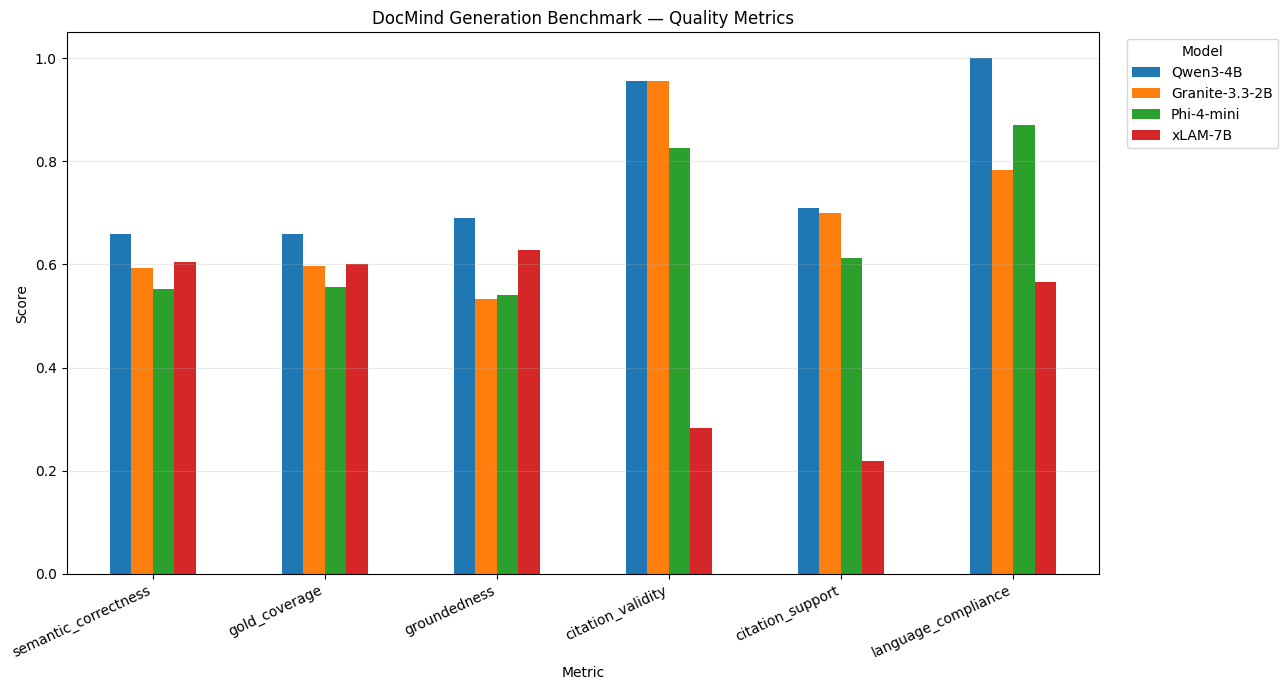

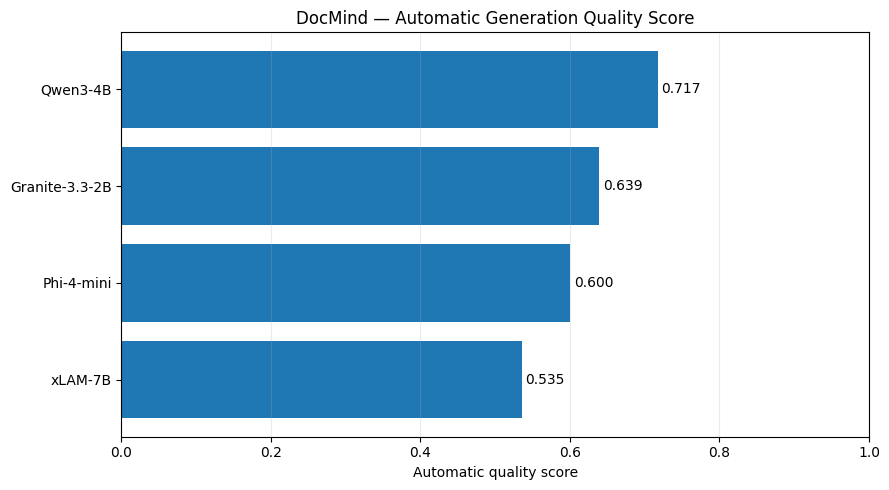

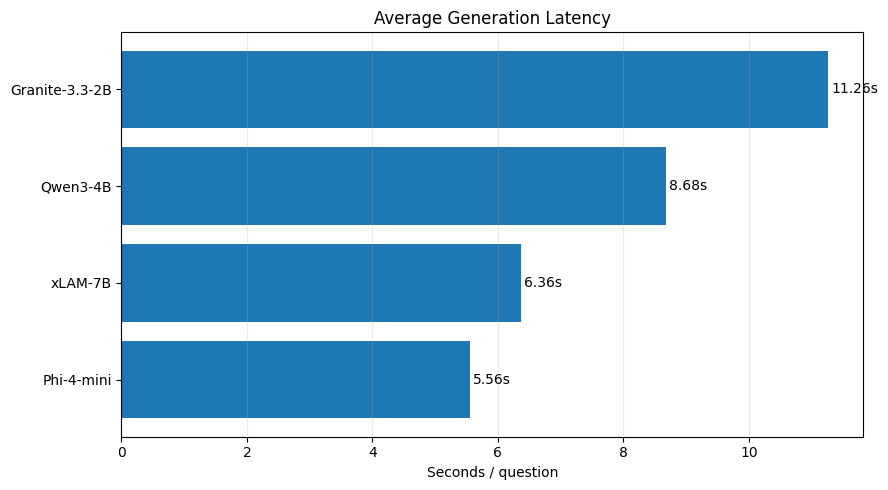

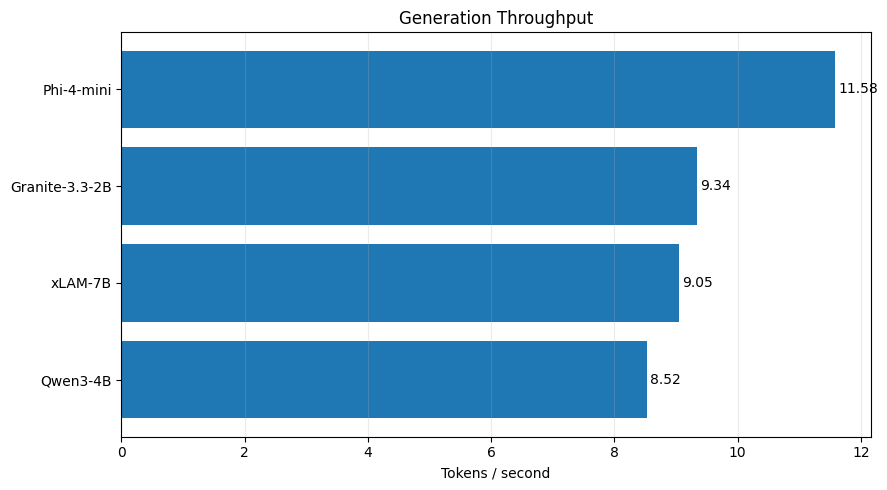

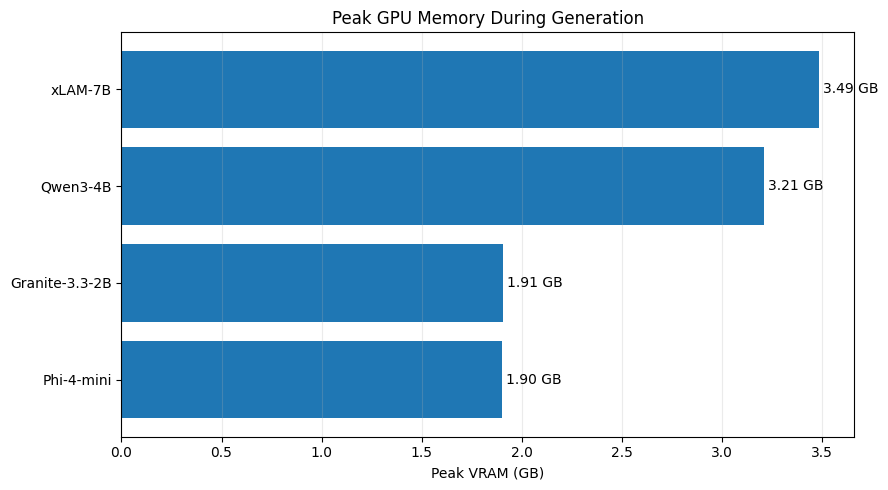

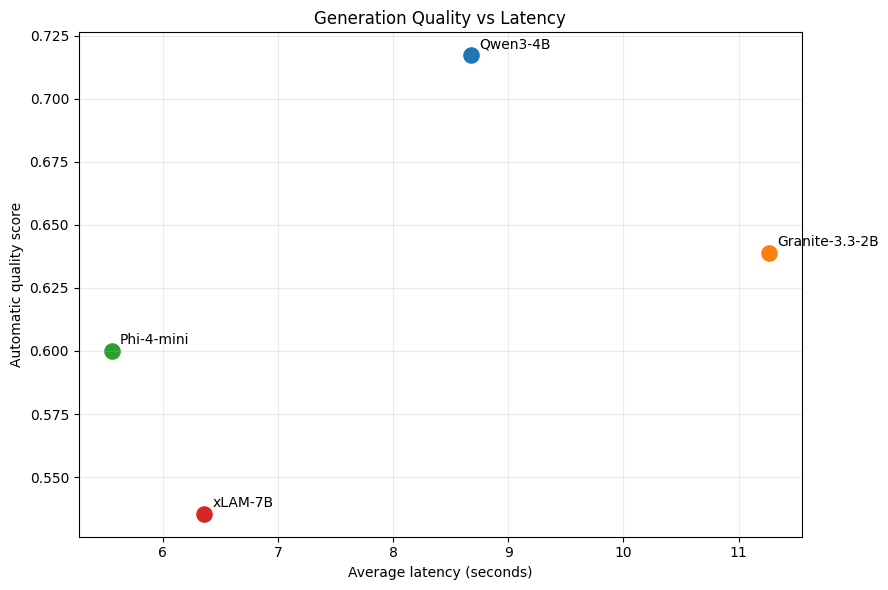

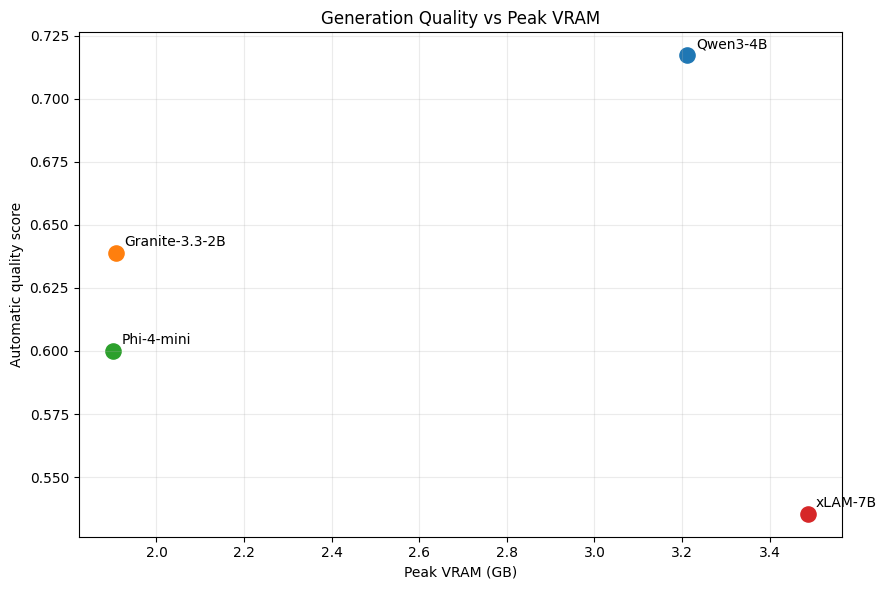



QUESTION-BY-QUESTION AUTOMATIC WINS


,model,questions_won
0,Qwen3-4B,34
1,Phi-4-mini,10
2,xLAM-7B,1
3,Granite-3.3-2B,1




TOP 10 QUESTIONS WHERE MODELS DIFFER MOST


model,Granite-3.3-2B,Phi-4-mini,Qwen3-4B,xLAM-7B,score_range
question_id,,,,,
q058,0.680551,0.001382,0.852714,0.537973,0.851332
q008,0.635192,0.785873,0.838337,0.000000,0.838337
q012,0.639141,0.000000,0.836014,0.532347,0.836014
q020,0.620585,0.000000,0.720616,0.484772,0.720616
q003,0.617045,0.009240,0.676785,0.545722,0.667545
q005,0.698159,0.675849,0.787686,0.211154,0.576532
q032,0.373167,0.037731,0.555398,0.307783,0.517666
q010,0.376658,0.052685,0.535243,0.361737,0.482558
q018,0.770322,0.875938,0.897414,0.439884,0.457529





SHAREABLE BENCHMARK REPORT

# DocMind Grounded Generation Benchmark — DEV

Evaluated **46 answerable DEV questions** using the exact same frozen top-5 retrieved context for every model.

## Models
- Qwen3-4B
- Phi-4-mini
- Granite-3.3-2B
- xLAM-7B

## Provisional automatic winner

**Qwen3-4B** ranked first by the transparent automatic quality score at **0.7173**.

This score combines semantic answer similarity, gold-answer coverage, source groundedness, citation validity, citation support, and language compliance.

## Quality leaders

- Highest semantic correctness proxy: **Qwen3-4B** (0.6593)
- Highest groundedness proxy: **Qwen3-4B** (0.6908)

## Efficiency leaders

- Lowest average latency: **Phi-4-mini** (5.556 s/question)
- Highest generation throughput: **Phi-4-mini** (11.58 tokens/s)
- Lowest peak VRAM: **Phi-4-mini** (1.90 GB)

## Full summary

| Model | Correctness | Coverage | Groundedness | Citation validity | Language | Quality | Latency | tok/s | VRAM |
|---|---:|---:|-

In [59]:
# ============================================================
# DOCMIND — COMPLETE 3-MODEL GENERATION BENCHMARK REPORT
#
# Models:
#   - Qwen3-4B
#   - Phi-4-mini
#   - Granite-3.3-2B
#
# IMPORTANT:
# Automatic semantic metrics below are PROXIES.
# They are useful for model comparison, but they are not a
# replacement for human / independent LLM judging.
# ============================================================

import os
import re
import gc
import sys
import json
import math
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. CLEAN GPU MEMORY
# ============================================================

try:
    import torch

    # Remove previously loaded generation model if still present.
    globals().pop("model", None)
    globals().pop("tokenizer", None)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

except Exception:
    torch = None


# ============================================================
# 1. INSTALL SMALL EVALUATION DEPENDENCIES IF NEEDED
# ============================================================

def ensure_package(package, import_name=None):

    import_name = import_name or package

    if importlib.util.find_spec(import_name) is None:

        print(f"Installing {package} ...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ])


ensure_package(
    "sentence-transformers",
    "sentence_transformers"
)

ensure_package(
    "langdetect",
    "langdetect"
)


from sentence_transformers import SentenceTransformer
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0


# ============================================================
# 2. PATHS
# ============================================================

GENERATION_OUTPUT_DIR = Path(
    "/kaggle/working/docmind_generation_results"
)

REPORT_DIR = Path(
    "/kaggle/working/docmind_generation_report"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLOT_DIR = REPORT_DIR / "plots"

PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_FILES = {

    "Qwen3-4B":
        GENERATION_OUTPUT_DIR /
        "qwen3_4b__dev_generations.json",

    "Phi-4-mini":
        GENERATION_OUTPUT_DIR /
        "phi4_mini__dev_generations.json",

    "Granite-3.3-2B":
        GENERATION_OUTPUT_DIR /
        "granite_2b__dev_generations.json",

    "xLAM-7B":
        GENERATION_OUTPUT_DIR /
        "xlam_7b__dev_generations.json",
}


# ============================================================
# 3. FIND FROZEN BENCHMARK
# ============================================================

benchmark_matches = list(
    Path("/kaggle").rglob(
        "docmind_generation_dev_frozen.json"
    )
)

assert benchmark_matches, (
    "Could not find docmind_generation_dev_frozen.json"
)

BENCHMARK_PATH = benchmark_matches[0]

print("Benchmark:", BENCHMARK_PATH)


with open(
    BENCHMARK_PATH,
    "r",
    encoding="utf-8"
) as f:

    benchmark = json.load(f)


benchmark_records = benchmark["records"]

benchmark_lookup = {
    r["question_id"]: r
    for r in benchmark_records
}


print(
    "Frozen benchmark questions:",
    len(benchmark_records)
)


# ============================================================
# 4. LOAD ALL THREE MODEL RUNS
# ============================================================

model_dfs = {}

for model_name, path in MODEL_FILES.items():

    assert path.exists(), (
        f"\nMissing results for {model_name}\n"
        f"Expected:\n{path}\n\n"
        f"Run the full 46-question benchmark first."
    )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        data = json.load(f)

    df = pd.DataFrame(data)

    assert len(df) == len(benchmark_records), (
        f"{model_name}: expected "
        f"{len(benchmark_records)} questions, "
        f"got {len(df)}"
    )

    assert df["question_id"].is_unique, (
        f"{model_name}: duplicate question IDs"
    )

    model_dfs[model_name] = df


# Verify exact same question IDs
expected_ids = set(
    benchmark_lookup.keys()
)

for model_name, df in model_dfs.items():

    ids = set(
        df["question_id"]
    )

    assert ids == expected_ids, (
        f"{model_name}: question IDs do not "
        "match frozen benchmark."
    )


print("\n✅ All three runs loaded")
print("✅ Same questions confirmed")
print("✅ Questions/model:", len(expected_ids))


# ============================================================
# 5. AUTOMATIC SEMANTIC EVALUATOR
#
# Independent small multilingual embedding model.
#
# This is NOT used by the RAG system itself.
# It is used only as an evaluation proxy.
# ============================================================

EVALUATOR_MODEL = (
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

eval_device = (
    "cuda"
    if (
        torch is not None
        and torch.cuda.is_available()
    )
    else "cpu"
)

print(
    "\nLoading evaluator:",
    EVALUATOR_MODEL
)

print(
    "Evaluator device:",
    eval_device
)

evaluator = SentenceTransformer(
    EVALUATOR_MODEL,
    device=eval_device
)


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

CITATION_PATTERN = re.compile(
    r"\[S(\d+)\]"
)


def clean_text(text):

    if text is None:
        return ""

    return str(text).strip()


def split_sentences(text):

    text = clean_text(text)

    pieces = re.split(
        r"(?<=[.!?؟])\s+|\n+",
        text
    )

    return [
        p.strip()
        for p in pieces
        if len(p.strip()) >= 3
    ]


def split_gold_units(text):

    text = clean_text(text)

    # Gold answers are mostly short.
    # Split only on strong boundaries.
    pieces = re.split(
        r"[.;!?؟]\s*|\n+",
        text
    )

    return [
        p.strip()
        for p in pieces
        if len(p.strip()) >= 3
    ]


def cosine(a, b):

    # Embeddings are normalized
    value = float(
        np.dot(a, b)
    )

    return float(
        np.clip(
            value,
            0.0,
            1.0
        )
    )


def detect_language_safe(text):

    text = clean_text(text)

    if len(text) < 5:
        return "unknown"

    try:
        return detect(text)

    except Exception:
        return "unknown"


def extract_citations(text):

    return [
        int(x)
        for x in CITATION_PATTERN.findall(
            clean_text(text)
        )
    ]


def repetition_rate(text):

    sentences = split_sentences(text)

    if len(sentences) <= 1:
        return 0.0

    normalized = [
        re.sub(
            r"\W+",
            " ",
            s.lower()
        ).strip()
        for s in sentences
    ]

    unique = len(
        set(normalized)
    )

    return 1.0 - (
        unique / len(normalized)
    )


# ============================================================
# 7. BUILD TEXT POOL
#
# Encode every unique answer, gold answer, source,
# answer sentence and gold unit once.
# ============================================================

all_texts = set()


for model_name, df in model_dfs.items():

    for _, row in df.iterrows():

        qid = row["question_id"]

        answer = clean_text(
            row["answer"]
        )

        gold = clean_text(
            row["expected_answer"]
        )

        all_texts.add(answer)
        all_texts.add(gold)

        for sentence in split_sentences(answer):
            all_texts.add(sentence)

        for unit in split_gold_units(gold):
            all_texts.add(unit)

        record = benchmark_lookup[qid]

        for ctx in record["contexts"]:
            all_texts.add(
                clean_text(ctx["text"])
            )


all_texts.discard("")

all_texts = list(
    all_texts
)


print(
    "\nUnique texts to embed:",
    len(all_texts)
)


# ============================================================
# 8. ENCODE TEXT POOL
# ============================================================

embeddings = evaluator.encode(
    all_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)


embedding_lookup = {
    text: emb
    for text, emb in zip(
        all_texts,
        embeddings
    )
}


print(
    "✅ Semantic evaluation embeddings ready"
)


# ============================================================
# 9. CALCULATE PER-QUESTION METRICS
# ============================================================

evaluation_rows = []


for model_name, df in model_dfs.items():

    for _, row in df.iterrows():

        qid = row["question_id"]

        record = benchmark_lookup[
            qid
        ]

        answer = clean_text(
            row["answer"]
        )

        gold = clean_text(
            row["expected_answer"]
        )

        contexts = record[
            "contexts"
        ]

        context_texts = [
            clean_text(c["text"])
            for c in contexts
        ]

        # --------------------------------------------
        # A. SEMANTIC CORRECTNESS PROXY
        # --------------------------------------------

        answer_emb = embedding_lookup[
            answer
        ]

        gold_emb = embedding_lookup[
            gold
        ]

        semantic_correctness = cosine(
            answer_emb,
            gold_emb
        )


        # --------------------------------------------
        # B. GOLD ANSWER COVERAGE / COMPLETENESS PROXY
        #
        # Each gold information unit should be
        # semantically represented by the answer.
        # --------------------------------------------

        gold_units = split_gold_units(
            gold
        )

        gold_unit_scores = []

        for unit in gold_units:

            unit_emb = embedding_lookup[
                unit
            ]

            gold_unit_scores.append(
                cosine(
                    unit_emb,
                    answer_emb
                )
            )

        gold_coverage = (
            float(
                np.mean(
                    gold_unit_scores
                )
            )
            if gold_unit_scores
            else semantic_correctness
        )


        # --------------------------------------------
        # C. GROUNDEDNESS PROXY
        #
        # For every generated sentence:
        # find its best semantic match among
        # the five retrieved source chunks.
        # --------------------------------------------

        answer_sentences = (
            split_sentences(answer)
        )

        context_embeddings = [
            embedding_lookup[text]
            for text in context_texts
        ]

        grounding_scores = []

        for sentence in answer_sentences:

            s_emb = embedding_lookup[
                sentence
            ]

            similarities = [
                cosine(
                    s_emb,
                    c_emb
                )
                for c_emb
                in context_embeddings
            ]

            if similarities:
                grounding_scores.append(
                    max(similarities)
                )

        groundedness = (
            float(
                np.mean(
                    grounding_scores
                )
            )
            if grounding_scores
            else 0.0
        )


        # --------------------------------------------
        # D. CITATION METRICS
        # --------------------------------------------

        citations = extract_citations(
            answer
        )

        valid_citations = [
            c
            for c in citations
            if 1 <= c <= len(contexts)
        ]

        citation_present = float(
            len(citations) > 0
        )

        citation_validity = (
            len(valid_citations)
            / len(citations)
            if citations
            else 0.0
        )


        # --------------------------------------------
        # E. CITATION SUPPORT PROXY
        #
        # Compare answer to specifically cited
        # passages rather than all passages.
        # --------------------------------------------

        citation_support_scores = []

        for citation_num in valid_citations:

            cited_text = context_texts[
                citation_num - 1
            ]

            cited_emb = embedding_lookup[
                cited_text
            ]

            citation_support_scores.append(
                cosine(
                    answer_emb,
                    cited_emb
                )
            )

        citation_support = (
            float(
                np.mean(
                    citation_support_scores
                )
            )
            if citation_support_scores
            else 0.0
        )


        # --------------------------------------------
        # F. LANGUAGE COMPLIANCE
        # --------------------------------------------

        expected_language = str(
            row["language"]
        ).lower()

        detected_language = (
            detect_language_safe(
                answer
            )
        )

        language_match = float(
            detected_language
            == expected_language
        )


        # --------------------------------------------
        # G. STYLE / CONCISENESS
        # --------------------------------------------

        answer_words = len(
            answer.split()
        )

        gold_words = max(
            len(gold.split()),
            1
        )

        verbosity_ratio = (
            answer_words
            / gold_words
        )

        repeat_rate = repetition_rate(
            answer
        )


        # --------------------------------------------
        # H. EFFICIENCY
        # --------------------------------------------

        latency = float(
            row["latency_seconds"]
        )

        tps = float(
            row["tokens_per_second"]
        )

        output_tokens = int(
            row["generated_tokens"]
        )

        peak_vram = float(
            row["peak_vram_gb"]
        )


        # --------------------------------------------
        # I. TRANSPARENT AUTOMATIC QUALITY SCORE
        #
        # IMPORTANT:
        # This is a comparison score, NOT ground truth.
        #
        # Correctness       35%
        # Gold coverage     20%
        # Groundedness      20%
        # Citation validity 10%
        # Citation support  10%
        # Language           5%
        # --------------------------------------------

        quality_score = (
            0.35 * semantic_correctness
            +
            0.20 * gold_coverage
            +
            0.20 * groundedness
            +
            0.10 * citation_validity
            +
            0.10 * citation_support
            +
            0.05 * language_match
        )


        evaluation_rows.append({

            "model":
                model_name,

            "question_id":
                qid,

            "language":
                expected_language,

            "question_type":
                row["question_type"],

            "question":
                row["question"],

            "gold_answer":
                gold,

            "generated_answer":
                answer,

            "semantic_correctness":
                semantic_correctness,

            "gold_coverage":
                gold_coverage,

            "groundedness":
                groundedness,

            "citation_present":
                citation_present,

            "citation_validity":
                citation_validity,

            "citation_support":
                citation_support,

            "language_detected":
                detected_language,

            "language_match":
                language_match,

            "repetition_rate":
                repeat_rate,

            "answer_words":
                answer_words,

            "verbosity_ratio":
                verbosity_ratio,

            "latency_seconds":
                latency,

            "tokens_per_second":
                tps,

            "generated_tokens":
                output_tokens,

            "peak_vram_gb":
                peak_vram,

            "automatic_quality_score":
                quality_score,
        })


EVAL_DF = pd.DataFrame(
    evaluation_rows
)


print(
    "\n✅ Per-question evaluation finished"
)

print(
    "Rows:",
    len(EVAL_DF)
)


# ============================================================
# 10. MODEL SUMMARY
# ============================================================

SUMMARY = (
    EVAL_DF
    .groupby("model")
    .agg(

        questions=(
            "question_id",
            "count"
        ),

        semantic_correctness=(
            "semantic_correctness",
            "mean"
        ),

        gold_coverage=(
            "gold_coverage",
            "mean"
        ),

        groundedness=(
            "groundedness",
            "mean"
        ),

        citation_presence=(
            "citation_present",
            "mean"
        ),

        citation_validity=(
            "citation_validity",
            "mean"
        ),

        citation_support=(
            "citation_support",
            "mean"
        ),

        language_compliance=(
            "language_match",
            "mean"
        ),

        repetition_rate=(
            "repetition_rate",
            "mean"
        ),

        avg_verbosity_ratio=(
            "verbosity_ratio",
            "mean"
        ),

        avg_output_tokens=(
            "generated_tokens",
            "mean"
        ),

        avg_latency_s=(
            "latency_seconds",
            "mean"
        ),

        median_latency_s=(
            "latency_seconds",
            "median"
        ),

        avg_tokens_per_second=(
            "tokens_per_second",
            "mean"
        ),

        peak_vram_gb=(
            "peak_vram_gb",
            "max"
        ),

        automatic_quality_score=(
            "automatic_quality_score",
            "mean"
        ),
    )
    .reset_index()
)


SUMMARY = (
    SUMMARY
    .sort_values(
        [
            "automatic_quality_score",
            "semantic_correctness",
            "groundedness"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


SUMMARY.insert(
    0,
    "rank",
    np.arange(
        1,
        len(SUMMARY) + 1
    )
)


# ============================================================
# 11. DISPLAY MAIN LEADERBOARD
# ============================================================

print("\n")
print("=" * 110)
print("DOCMIND GENERATION BENCHMARK — DEV LEADERBOARD")
print("=" * 110)


display(
    SUMMARY.style.format({

        "semantic_correctness":
            "{:.4f}",

        "gold_coverage":
            "{:.4f}",

        "groundedness":
            "{:.4f}",

        "citation_presence":
            "{:.4f}",

        "citation_validity":
            "{:.4f}",

        "citation_support":
            "{:.4f}",

        "language_compliance":
            "{:.4f}",

        "repetition_rate":
            "{:.4f}",

        "avg_verbosity_ratio":
            "{:.2f}",

        "avg_output_tokens":
            "{:.1f}",

        "avg_latency_s":
            "{:.3f}",

        "median_latency_s":
            "{:.3f}",

        "avg_tokens_per_second":
            "{:.2f}",

        "peak_vram_gb":
            "{:.2f}",

        "automatic_quality_score":
            "{:.4f}",
    })
)


# ============================================================
# 12. PERFORMANCE BY LANGUAGE
# ============================================================

LANGUAGE_SUMMARY = (
    EVAL_DF
    .groupby([
        "model",
        "language"
    ])
    .agg(

        questions=(
            "question_id",
            "count"
        ),

        correctness=(
            "semantic_correctness",
            "mean"
        ),

        groundedness=(
            "groundedness",
            "mean"
        ),

        quality=(
            "automatic_quality_score",
            "mean"
        ),

        language_compliance=(
            "language_match",
            "mean"
        ),
    )
    .reset_index()
)


print("\n")
print("=" * 110)
print("PERFORMANCE BY LANGUAGE")
print("=" * 110)

display(
    LANGUAGE_SUMMARY.style.format({
        "correctness": "{:.4f}",
        "groundedness": "{:.4f}",
        "quality": "{:.4f}",
        "language_compliance": "{:.4f}",
    })
)


# ============================================================
# 13. PERFORMANCE BY QUESTION TYPE
# ============================================================

TYPE_SUMMARY = (
    EVAL_DF
    .groupby([
        "model",
        "question_type"
    ])
    .agg(

        questions=(
            "question_id",
            "count"
        ),

        correctness=(
            "semantic_correctness",
            "mean"
        ),

        groundedness=(
            "groundedness",
            "mean"
        ),

        quality=(
            "automatic_quality_score",
            "mean"
        ),
    )
    .reset_index()
)


print("\n")
print("=" * 110)
print("PERFORMANCE BY QUESTION TYPE")
print("=" * 110)

display(
    TYPE_SUMMARY.style.format({
        "correctness": "{:.4f}",
        "groundedness": "{:.4f}",
        "quality": "{:.4f}",
    })
)


# ============================================================
# 14. PLOT — MAIN QUALITY METRICS
# ============================================================

quality_metrics = [
    "semantic_correctness",
    "gold_coverage",
    "groundedness",
    "citation_validity",
    "citation_support",
    "language_compliance"
]


quality_plot = (
    SUMMARY
    .set_index("model")[
        quality_metrics
    ]
    .T
)


ax = quality_plot.plot(
    kind="bar",
    figsize=(13, 7)
)

ax.set_title(
    "DocMind Generation Benchmark — Quality Metrics"
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "Metric"
)

ax.set_ylim(
    0,
    1.05
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

path = (
    PLOT_DIR /
    "01_generation_quality_metrics.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. PLOT — AUTOMATIC QUALITY SCORE
# ============================================================

quality_ranked = (
    SUMMARY
    .sort_values(
        "automatic_quality_score",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    quality_ranked["model"],
    quality_ranked[
        "automatic_quality_score"
    ]
)

ax.set_title(
    "DocMind — Automatic Generation Quality Score"
)

ax.set_xlabel(
    "Automatic quality score"
)

ax.set_xlim(
    0,
    1.0
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    quality_ranked[
        "automatic_quality_score"
    ]
):

    ax.text(
        value + 0.005,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.3f}",

        va="center"
    )

plt.tight_layout()

path = (
    PLOT_DIR /
    "02_automatic_quality_score.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. PLOT — LATENCY
# ============================================================

latency_ranked = (
    SUMMARY
    .sort_values(
        "avg_latency_s",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    latency_ranked["model"],
    latency_ranked[
        "avg_latency_s"
    ]
)

ax.set_title(
    "Average Generation Latency"
)

ax.set_xlabel(
    "Seconds / question"
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    latency_ranked[
        "avg_latency_s"
    ]
):

    ax.text(
        value + 0.05,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.2f}s",

        va="center"
    )

plt.tight_layout()

path = (
    PLOT_DIR /
    "03_average_latency.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. PLOT — TOKENS / SECOND
# ============================================================

speed_ranked = (
    SUMMARY
    .sort_values(
        "avg_tokens_per_second",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    speed_ranked["model"],
    speed_ranked[
        "avg_tokens_per_second"
    ]
)

ax.set_title(
    "Generation Throughput"
)

ax.set_xlabel(
    "Tokens / second"
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    speed_ranked[
        "avg_tokens_per_second"
    ]
):

    ax.text(
        value + 0.05,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.2f}",

        va="center"
    )

plt.tight_layout()

path = (
    PLOT_DIR /
    "04_tokens_per_second.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. PLOT — VRAM
# ============================================================

vram_ranked = (
    SUMMARY
    .sort_values(
        "peak_vram_gb",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    vram_ranked["model"],
    vram_ranked[
        "peak_vram_gb"
    ]
)

ax.set_title(
    "Peak GPU Memory During Generation"
)

ax.set_xlabel(
    "Peak VRAM (GB)"
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    vram_ranked[
        "peak_vram_gb"
    ]
):

    ax.text(
        value + 0.02,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.2f} GB",

        va="center"
    )

plt.tight_layout()

path = (
    PLOT_DIR /
    "05_peak_vram.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. PLOT — QUALITY VS LATENCY
#
# Ideal position:
# upper-left
# high quality + low latency
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


for _, row in SUMMARY.iterrows():

    ax.scatter(
        row["avg_latency_s"],
        row[
            "automatic_quality_score"
        ],
        s=120
    )

    ax.annotate(

        row["model"],

        (
            row["avg_latency_s"],
            row[
                "automatic_quality_score"
            ]
        ),

        xytext=(6, 5),

        textcoords="offset points"
    )


ax.set_title(
    "Generation Quality vs Latency"
)

ax.set_xlabel(
    "Average latency (seconds)"
)

ax.set_ylabel(
    "Automatic quality score"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

path = (
    PLOT_DIR /
    "06_quality_vs_latency.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. PLOT — QUALITY VS VRAM
#
# Ideal position:
# upper-left
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


for _, row in SUMMARY.iterrows():

    ax.scatter(
        row["peak_vram_gb"],
        row[
            "automatic_quality_score"
        ],
        s=120
    )

    ax.annotate(

        row["model"],

        (
            row["peak_vram_gb"],
            row[
                "automatic_quality_score"
            ]
        ),

        xytext=(6, 5),

        textcoords="offset points"
    )


ax.set_title(
    "Generation Quality vs Peak VRAM"
)

ax.set_xlabel(
    "Peak VRAM (GB)"
)

ax.set_ylabel(
    "Automatic quality score"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

path = (
    PLOT_DIR /
    "07_quality_vs_vram.png"
)

plt.savefig(
    path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. FIND QUESTION-BY-QUESTION WINNERS
# ============================================================

best_by_question = (
    EVAL_DF
    .sort_values(
        [
            "question_id",
            "automatic_quality_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "question_id"
    )
    .first()
    .reset_index()
)


QUESTION_WIN_COUNTS = (
    best_by_question[
        "model"
    ]
    .value_counts()
    .rename_axis(
        "model"
    )
    .reset_index(
        name="questions_won"
    )
)


print("\n")
print("=" * 110)
print("QUESTION-BY-QUESTION AUTOMATIC WINS")
print("=" * 110)

display(
    QUESTION_WIN_COUNTS
)


# ============================================================
# 22. FIND CLOSE / DISAGREEMENT QUESTIONS
#
# Useful for manual inspection.
# ============================================================

quality_pivot = (
    EVAL_DF
    .pivot(
        index="question_id",
        columns="model",
        values="automatic_quality_score"
    )
)


quality_pivot[
    "score_range"
] = (
    quality_pivot.max(
        axis=1
    )
    -
    quality_pivot.min(
        axis=1
    )
)


MOST_DISAGREEMENT = (
    quality_pivot
    .sort_values(
        "score_range",
        ascending=False
    )
    .head(10)
)


print("\n")
print("=" * 110)
print("TOP 10 QUESTIONS WHERE MODELS DIFFER MOST")
print("=" * 110)

display(
    MOST_DISAGREEMENT
)


# ============================================================
# 23. SAVE EVERYTHING
# ============================================================

PER_QUESTION_PATH = (
    REPORT_DIR /
    "generation_comparison_per_question.csv"
)

SUMMARY_PATH = (
    REPORT_DIR /
    "generation_model_summary.csv"
)

LANGUAGE_PATH = (
    REPORT_DIR /
    "generation_language_summary.csv"
)

TYPE_PATH = (
    REPORT_DIR /
    "generation_question_type_summary.csv"
)

WIN_PATH = (
    REPORT_DIR /
    "generation_question_wins.csv"
)

JSON_SUMMARY_PATH = (
    REPORT_DIR /
    "generation_model_summary.json"
)


EVAL_DF.to_csv(
    PER_QUESTION_PATH,
    index=False
)

SUMMARY.to_csv(
    SUMMARY_PATH,
    index=False
)

LANGUAGE_SUMMARY.to_csv(
    LANGUAGE_PATH,
    index=False
)

TYPE_SUMMARY.to_csv(
    TYPE_PATH,
    index=False
)

QUESTION_WIN_COUNTS.to_csv(
    WIN_PATH,
    index=False
)


with open(
    JSON_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        SUMMARY.to_dict(
            orient="records"
        ),
        f,
        ensure_ascii=False,
        indent=2
    )


# ============================================================
# 24. AUTOMATIC WRITTEN REPORT
# ============================================================

winner = SUMMARY.iloc[0]

fastest = (
    SUMMARY
    .sort_values(
        "avg_latency_s"
    )
    .iloc[0]
)

highest_tps = (
    SUMMARY
    .sort_values(
        "avg_tokens_per_second",
        ascending=False
    )
    .iloc[0]
)

lowest_vram = (
    SUMMARY
    .sort_values(
        "peak_vram_gb"
    )
    .iloc[0]
)

best_correctness = (
    SUMMARY
    .sort_values(
        "semantic_correctness",
        ascending=False
    )
    .iloc[0]
)

best_grounding = (
    SUMMARY
    .sort_values(
        "groundedness",
        ascending=False
    )
    .iloc[0]
)


report_lines = []

report_lines.append(
    "# DocMind Grounded Generation Benchmark — DEV"
)

report_lines.append("")

report_lines.append(
    f"Evaluated **{len(expected_ids)} answerable DEV questions** "
    "using the exact same frozen top-5 retrieved context for every model."
)

report_lines.append("")

report_lines.append(
    "## Models"
)

for model_name in MODEL_FILES:
    report_lines.append(
        f"- {model_name}"
    )

report_lines.append("")

report_lines.append(
    "## Provisional automatic winner"
)

report_lines.append("")

report_lines.append(
    f"**{winner['model']}** ranked first by the transparent "
    f"automatic quality score at "
    f"**{winner['automatic_quality_score']:.4f}**."
)

report_lines.append("")

report_lines.append(
    "This score combines semantic answer similarity, "
    "gold-answer coverage, source groundedness, citation validity, "
    "citation support, and language compliance."
)

report_lines.append("")

report_lines.append(
    "## Quality leaders"
)

report_lines.append("")

report_lines.append(
    f"- Highest semantic correctness proxy: "
    f"**{best_correctness['model']}** "
    f"({best_correctness['semantic_correctness']:.4f})"
)

report_lines.append(
    f"- Highest groundedness proxy: "
    f"**{best_grounding['model']}** "
    f"({best_grounding['groundedness']:.4f})"
)

report_lines.append("")

report_lines.append(
    "## Efficiency leaders"
)

report_lines.append("")

report_lines.append(
    f"- Lowest average latency: "
    f"**{fastest['model']}** "
    f"({fastest['avg_latency_s']:.3f} s/question)"
)

report_lines.append(
    f"- Highest generation throughput: "
    f"**{highest_tps['model']}** "
    f"({highest_tps['avg_tokens_per_second']:.2f} tokens/s)"
)

report_lines.append(
    f"- Lowest peak VRAM: "
    f"**{lowest_vram['model']}** "
    f"({lowest_vram['peak_vram_gb']:.2f} GB)"
)

report_lines.append("")

report_lines.append(
    "## Full summary"
)

report_lines.append("")

report_lines.append(
    "| Model | Correctness | Coverage | Groundedness | Citation validity | Language | Quality | Latency | tok/s | VRAM |"
)

report_lines.append(
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|"
)


for _, r in SUMMARY.iterrows():

    report_lines.append(

        f"| {r['model']} "
        f"| {r['semantic_correctness']:.4f} "
        f"| {r['gold_coverage']:.4f} "
        f"| {r['groundedness']:.4f} "
        f"| {r['citation_validity']:.4f} "
        f"| {r['language_compliance']:.4f} "
        f"| {r['automatic_quality_score']:.4f} "
        f"| {r['avg_latency_s']:.3f}s "
        f"| {r['avg_tokens_per_second']:.2f} "
        f"| {r['peak_vram_gb']:.2f} GB |"
    )


report_lines.append("")

report_lines.append(
    "## Methodological note"
)

report_lines.append("")

report_lines.append(
    "Semantic correctness, completeness, groundedness, and citation "
    "support are automated embedding-based proxy metrics. They should "
    "not be interpreted as perfect factual judgments. The final model "
    "selection should also include manual inspection or an independent "
    "judge on disagreement cases."
)

report_lines.append("")

report_lines.append(
    "The current DEV generation benchmark contains only answerable "
    "questions, so refusal/no-answer accuracy is not measured here."
)

report_lines.append("")

report_lines.append(
    "The held-out TEST split has not been used for model selection."
)


REPORT_TEXT = "\n".join(
    report_lines
)


REPORT_MD_PATH = (
    REPORT_DIR /
    "DOCMIND_GENERATION_BENCHMARK_REPORT.md"
)


with open(
    REPORT_MD_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        REPORT_TEXT
    )


# ============================================================
# 25. PRINT SHAREABLE REPORT
# ============================================================

print("\n\n")
print("=" * 110)
print("SHAREABLE BENCHMARK REPORT")
print("=" * 110)
print()

print(
    REPORT_TEXT
)


# ============================================================
# 26. FINAL FILE LIST
# ============================================================

print("\n")
print("=" * 110)
print("FILES CREATED")
print("=" * 110)

print(
    "\nMain summary:"
)

print(
    SUMMARY_PATH
)

print(
    "\nPer-question comparison:"
)

print(
    PER_QUESTION_PATH
)

print(
    "\nWritten report:"
)

print(
    REPORT_MD_PATH
)

print(
    "\nPlots:"
)

for p in sorted(
    PLOT_DIR.glob("*.png")
):
    print(
        " -",
        p
    )


print("\n✅ DOCMIND GENERATION COMPARISON COMPLETE")

In [56]:
def load_text_llm(model_key):

    clear_llm()

    cfg = GENERATION_MODELS[
        model_key
    ]

    print(
        "Loading:",
        cfg["model_name"]
    )

    tokenizer = AutoTokenizer.from_pretrained(
        cfg["model_name"],
        trust_remote_code=
            cfg["trust_remote_code"]
    )

    model = AutoModelForCausalLM.from_pretrained(
        cfg["model_name"],

        quantization_config=
            QUANT_CONFIG,

        # Keep benchmark on one GPU
        device_map={
            "": 0
        },

        trust_remote_code=
            cfg["trust_remote_code"]
    )

    model.eval()

    print(
        "✅ Loaded:",
        model_key
    )

    print(
        "4-bit:",
        getattr(
            model,
            "is_loaded_in_4bit",
            False
        )
    )

    print(
        "Model memory footprint:",
        round(
            model.get_memory_footprint()
            / 1024**3,
            2
        ),
        "GB"
    )

    return tokenizer, model

In [57]:
tokenizer, model = load_text_llm(
    "xlam_7b"
)

Loading: Salesforce/xLAM-7b-r


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✅ Loaded: xlam_7b
4-bit: True
Model memory footprint: 3.74 GB


In [58]:
print("=" * 70)
print("XLAM QUANTIZATION CHECK")
print("=" * 70)

print(
    "Loaded in 4-bit:",
    getattr(
        model,
        "is_loaded_in_4bit",
        False
    )
)

print(
    "Memory footprint:",
    round(
        model.get_memory_footprint()
        / 1024**3,
        3
    ),
    "GB"
)

print(
    "\nQuantization config:"
)

print(
    getattr(
        model.config,
        "quantization_config",
        None
    )
)

if torch.cuda.is_available():

    print(
        "\nCUDA allocated:",
        round(
            torch.cuda.memory_allocated(0)
            / 1024**3,
            3
        ),
        "GB"
    )

    print(
        "CUDA reserved:",
        round(
            torch.cuda.memory_reserved(0)
            / 1024**3,
            3
        ),
        "GB"
    )

XLAM QUANTIZATION CHECK
Loaded in 4-bit: True
Memory footprint: 3.739 GB

Quantization config:
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}


CUDA allocated: 5.797 GB
CUDA reserved: 5.932 GB


In [61]:

clear_llm()